In [ ]:
#here lets see how to make a parallel workflow in the langgraph ``

from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv  
from langchain_groq import ChatGroq 
from typing import TypedDict
from langchain.prompts import PromptTemplate 
from pydantic import BaseModel ,Field

In [103]:
load_dotenv()

True

In [104]:
#lets load a llm model that supports the structured output 
llm=ChatGroq(model='Llama3-70b-8192') 



In [ ]:
#in this we have to get the feedback text and also the score 
#so we have to use the structured output using the pydantic so that our llm generates the 
#structure json output as requirements 

from typing import Annotated,operator 
class EvaluationSchema(BaseModel):
    feedback: str=Field(description='Detailed feedback of essay ') 
    score: int=Field(description='Score out of 10',ge=0,le=10)
    
    
structured_model=llm.with_structured_output(EvaluationSchema)

In [106]:
#lets see the output for our structure model 
essay='''Introduction
Pollution is one of the most pressing issues facing our planet today. It refers to the introduction of harmful substances or contaminants into the natural environment, leading to adverse effects on human health and the ecosystem. Pollution can take various forms, including air pollution, water pollution, soil pollution, and noise pollution, each with distinct causes and effects. Understanding pollution is crucial for protecting our planet and ensuring a sustainable future.
Types of Pollution
Air Pollution: This occurs when harmful substances are released into the atmosphere. Major contributors include industrial emissions, vehicular exhaust, and the burning of fossil fuels. Common pollutants include nitrogen oxides, sulfur dioxide, and particulate matter, which can lead to serious health problems such as respiratory diseases and heart conditions. Air pollution also contributes to global warming and climate change.
Water Pollution: Water bodies such as rivers, lakes, and oceans become contaminated due to the introduction of toxic chemicals, sewage, and industrial waste. This pollution can harm aquatic life and disrupt ecosystems. It also poses significant health risks to humans, leading to waterborne diseases like cholera and typhoid fever.
Soil Pollution: Soil contamination is caused by the excessive use of fertilizers, pesticides, and the improper disposal of industrial waste. Polluted soil affects plant growth and can lead to the accumulation of toxic substances in the food chain, posing risks to human health and agricultural productivity.
Noise Pollution: The term refers to excessive or harmful levels of noise in the environment, primarily from transportation, construction activities, and industrial operations. Noise pollution can lead to severe health issues, including stress, hearing loss, and sleep disturbances.
Causes of Pollution
The main causes of pollution are human activities. Rapid industrialization, urbanization, and population growth contribute significantly to the contamination of the environment. Some of the leading causes include:
Emissions from factories and vehicles
Agricultural runoff containing fertilizers and pesticides
Deforestation and habitat destruction
Improper waste management and disposal practices
Use of non-biodegradable materials
Effects on Health and Environment
Pollution has severe consequences for both human health and the environment.
Health Impacts: Exposure to pollutants can lead to a wide range of health issues, including respiratory diseases, heart conditions, and neurological disorders. Vulnerable populations, such as children and the elderly, are particularly at risk.
Ecosystem Damage: Pollution disrupts the balance of ecosystems, leading to the loss of biodiversity. Contaminated water bodies can result in the death of aquatic organisms, while air pollution contributes to climate change and habitat destruction.
Solutions to Combat Pollution
To address pollution effectively, a multi-faceted approach is necessary:
Government Regulations: Implementing and enforcing stricter environmental laws to limit emissions and waste disposal practices is essential. This includes promoting clean technologies and renewable energy sources.
Public Awareness: Raising awareness about pollution and its effects can encourage individuals and communities to adopt eco-friendly practices. Educational campaigns can foster a culture of sustainability.
Sustainable Practices: Encouraging industries to adopt waste reduction and recycling programs can significantly minimize pollution. Individuals can contribute by reducing their carbon footprint, using public transport, and minimizing single-use plastics.
Afforestation: Planting more trees helps improve air quality, reduces soil erosion, and restores degraded ecosystems. Forests play a crucial role in absorbing carbon dioxide and providing oxygen.
Conclusion
In conclusion, pollution poses a significant threat to our health and the environment. It is a complex issue requiring collective efforts from individuals, communities, governments, and industries to combat effectively. By understanding its causes and effects, we can take appropriate actions to mitigate pollution and work towards a cleaner, healthier planet for future generations. Emphasizing sustainable practices and raising awareness about the importance of protecting the environment is crucial for ensuring a sustainable future.'''

In [107]:
prompt =f'''Evaluate the language quality of the following essay and provide a feedback and assign a score our of 10 \n

{essay} '''
#lets invoke our model and see its structured output 
output=structured_model.invoke(prompt)


In [108]:
#lets see the output in a structured way so we can understand it 

display(Markdown(output.feedback))
output.score

The essay provides a comprehensive overview of pollution, its types, causes, effects, and potential solutions. The writer's use of clear and concise language makes the text easy to understand. The organization of the essay is logical, and the writer successfully transitions between paragraphs. However, there are some areas that require improvement. Some sentences are quite long and convoluted, making them difficult to follow. Additionally, the writer could benefit from using more specific examples and evidence to support their claims. The conclusion is well-written, but it could be stronger with a more thought-provoking final sentence.

8

In [109]:
#lets create our workflow 
class Essay_Evaluation_state(TypedDict):
    essay: str 
    language_feedback: str 
    analysis_feedback: str 
    clarity_feedback: str 
    overall_feedback: str 
    # individual_scores: list[int]
    #here we have to use the reducer because all node merge their data in the individual score 
    #lets make it 
    individual_scores: Annotated[list[int],operator.add] #here add is a reducer function 
    #by operator.add we can do [1]+[2]+[3]=[1,2,3]
    avg_score: float 

In [110]:
#lets make the logic for the node 
# This following code is for the structured output generation from the llm model 
class EvaluationSchema(BaseModel):
    feedback: str=Field(description='Detailed feedback of essay ') 
    score: int=Field(description='Score out of 10',ge=0,le=10)

llm=ChatGroq(model='Llama3-70b-8192') 
structured_model=llm.with_structured_output(EvaluationSchema)



def Evaluate_language(state: Essay_Evaluation_state)-> Essay_Evaluation_state: 
    essay=state['essay'] 
    
    #we have made the structured model above only we have to change the prompt for that 
    
    prompt=f'Evaluate the language quality of following essay and provide a feedback and assign a score out of 10   \n {essay}'
    response=structured_model.invoke(prompt)
    feedback=response.feedback 
    score=response.score 
    return {'language_feedback':feedback,'individual_scores':[score]}



def Evaluate_analysis (state: Essay_Evaluation_state)-> Essay_Evaluation_state: 
    essay=state['essay'] 
    
    #we have made the structured model above only we have to change the prompt for that 
    
    prompt=f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10   \n {essay}'
    response=structured_model.invoke(prompt)
    feedback=response.feedback 
    score=response.score 
    return {'analysis_feedback':feedback,'individual_scores':[score]}
    
    
    
    
    
def Evaluate_thought(state: Essay_Evaluation_state)-> Essay_Evaluation_state: 
    essay=state['essay'] 
    
    #we have made the structured model above only we have to change the prompt for that 
    
    prompt=f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10   \n {essay}'
    response=structured_model.invoke(prompt)
    feedback=response.feedback
    
    score=response.score 
    return {'clarity_feedback':feedback,'individual_scores':[score]}
    
    
    
    
    
def Overall_evaluation(state: Essay_Evaluation_state)-> Essay_Evaluation_state: 
    essay=state['essay'] 
    
    #we have made the structured model above only we have to change the prompt for that 
    
    prompt=f'Based on the following feedback create a summary of feedbacks   \n Language Feedback - {state['language_feedback']} \n Analysis Feedback - {state['analysis_feedback']} \n Clarity Feedback - {state['clarity_feedback']}'
    #here we don't need to add the structured model so here use the simple llm 
    response=llm.invoke(prompt)
    feedback=response.content
    #lets make the avg_score 
    avg_score=sum(state['individual_scores'])/len(state['individual_scores'])
   
    return {'overall_feedback':feedback,'avg_score':avg_score}




In [111]:
graph=StateGraph(Essay_Evaluation_state)

graph.add_node('evaluate_language',Evaluate_language) 
graph.add_node('evaluate_analysis',Evaluate_analysis)
graph.add_node('evaluate_thought',Evaluate_thought)
graph.add_node('overall_evaluation',Overall_evaluation)



#lets add edges 
graph.add_edge(START,'evaluate_analysis')
graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_thought')
graph.add_edge('evaluate_analysis','overall_evaluation')
graph.add_edge('evaluate_language','overall_evaluation')
graph.add_edge('evaluate_thought','overall_evaluation')

graph.add_edge('overall_evaluation',END)

In [112]:
#lets compile our graph and see its' gonna work or we have to do some more work on it 
workflow=graph.compile()

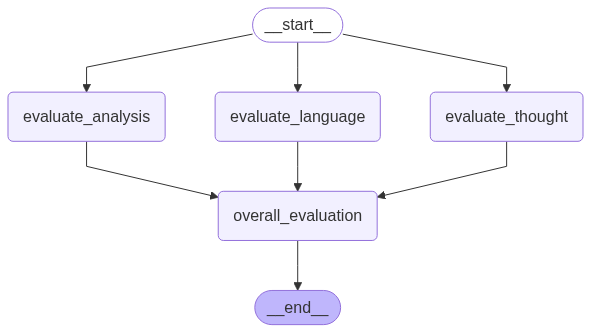

In [113]:
workflow #working fine 

In [114]:

essay='''Introduction
Pollution is one of the most pressing issues facing our planet today. It refers to the introduction of harmful substances or contaminants into the natural environment, leading to adverse effects on human health and the ecosystem. Pollution can take various forms, including air pollution, water pollution, soil pollution, and noise pollution, each with distinct causes and effects. Understanding pollution is crucial for protecting our planet and ensuring a sustainable future.
Types of Pollution
Air Pollution: This occurs when harmful substances are released into the atmosphere. Major contributors include industrial emissions, vehicular exhaust, and the burning of fossil fuels. Common pollutants include nitrogen oxides, sulfur dioxide, and particulate matter, which can lead to serious health problems such as respiratory diseases and heart conditions. Air pollution also contributes to global warming and climate change.
Water Pollution: Water bodies such as rivers, lakes, and oceans become contaminated due to the introduction of toxic chemicals, sewage, and industrial waste. This pollution can harm aquatic life and disrupt ecosystems. It also poses significant health risks to humans, leading to waterborne diseases like cholera and typhoid fever.
Soil Pollution: Soil contamination is caused by the excessive use of fertilizers, pesticides, and the improper disposal of industrial waste. Polluted soil affects plant growth and can lead to the accumulation of toxic substances in the food chain, posing risks to human health and agricultural productivity.
Noise Pollution: The term refers to excessive or harmful levels of noise in the environment, primarily from transportation, construction activities, and industrial operations. Noise pollution can lead to severe health issues, including stress, hearing loss, and sleep disturbances.
Causes of Pollution
The main causes of pollution are human activities. Rapid industrialization, urbanization, and population growth contribute significantly to the contamination of the environment. Some of the leading causes include:
Emissions from factories and vehicles
Agricultural runoff containing fertilizers and pesticides
Deforestation and habitat destruction
Improper waste management and disposal practices
Use of non-biodegradable materials
Effects on Health and Environment
Pollution has severe consequences for both human health and the environment.
Health Impacts: Exposure to pollutants can lead to a wide range of health issues, including respiratory diseases, heart conditions, and neurological disorders. Vulnerable populations, such as children and the elderly, are particularly at risk.
Ecosystem Damage: Pollution disrupts the balance of ecosystems, leading to the loss of biodiversity. Contaminated water bodies can result in the death of aquatic organisms, while air pollution contributes to climate change and habitat destruction.
Solutions to Combat Pollution
To address pollution effectively, a multi-faceted approach is necessary:
Government Regulations: Implementing and enforcing stricter environmental laws to limit emissions and waste disposal practices is essential. This includes promoting clean technologies and renewable energy sources.
Public Awareness: Raising awareness about pollution and its effects can encourage individuals and communities to adopt eco-friendly practices. Educational campaigns can foster a culture of sustainability.
Sustainable Practices: Encouraging industries to adopt waste reduction and recycling programs can significantly minimize pollution. Individuals can contribute by reducing their carbon footprint, using public transport, and minimizing single-use plastics.
Afforestation: Planting more trees helps improve air quality, reduces soil erosion, and restores degraded ecosystems. Forests play a crucial role in absorbing carbon dioxide and providing oxygen.
Conclusion
In conclusion, pollution poses a significant threat to our health and the environment. It is a complex issue requiring collective efforts from individuals, communities, governments, and industries to combat effectively. By understanding its causes and effects, we can take appropriate actions to mitigate pollution and work towards a cleaner, healthier planet for future generations. Emphasizing sustainable practices and raising awareness about the importance of protecting the environment is crucial for ensuring a sustainable future.'''

In [115]:
#lets call it 
initial_state={'essay':essay}
final_state=workflow.invoke(initial_state)

In [116]:
final_state

{'essay': 'Introduction\nPollution is one of the most pressing issues facing our planet today. It refers to the introduction of harmful substances or contaminants into the natural environment, leading to adverse effects on human health and the ecosystem. Pollution can take various forms, including air pollution, water pollution, soil pollution, and noise pollution, each with distinct causes and effects. Understanding pollution is crucial for protecting our planet and ensuring a sustainable future.\nTypes of Pollution\nAir Pollution: This occurs when harmful substances are released into the atmosphere. Major contributors include industrial emissions, vehicular exhaust, and the burning of fossil fuels. Common pollutants include nitrogen oxides, sulfur dioxide, and particulate matter, which can lead to serious health problems such as respiratory diseases and heart conditions. Air pollution also contributes to global warming and climate change.\nWater Pollution: Water bodies such as rivers